In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Overview

The Fraud Detection Dataset contains anonymized data related to financial transactions, with labels indicating whether each transaction is fraudulent. The key features include transactional details and metadata associated with each transaction, although specifics are masked for privacy.

## Steps should be performed :
### 1. Data Collection and Initial Exploration
● Dataset Link: Dataset.

● Data Overview: Import the dataset and inspect it to understand the number of features, labels, and any patterns.

● Check info, describe , Null values, column names, Duplicate columns or rows.

● Check and Handle Null values if present.

### 2.Data Preprocessing:
● Drop unwanted columns.

● Handling Imbalance data.
● Encoding Categorical Features: If there are any categorical features, encode them using techniques like One-Hot Encoding,Label Encoding.

### 3. Exploratory Data Analysis (EDA)
● Check Data Distribution.

● Fraud vs. Non-Fraud Transactions: Examine the number of fraudulent vs. non-fraudulent transactions.

● Correlations and Patterns: Use heatmaps or pair plots to analyze correlations between features.

### 4. Visualisation:
● Perform visualisation on different columns in the dataset.

● Must use: Boxplot, countplot, Heatmap, Pairplot, barplot.

### 5. Feature Scaling

### 6. Model Selection & Fitting:

● Train Test split , Fit any 4 model suitable for the dataset and compare the accuracies.

### 7. Model Evaluation :

● Classification report, F1 SCORE, Accuracy score, Confusion matrix.

## 1. Data Collection and Initial Exploration

● Dataset Link: Dataset.

● Data Overview: Import the dataset and inspect it to understand the number of features, labels, and any patterns.

● Check info, describe , Null values, column names, Duplicate columns or rows.

● Check and Handle Null values if present.

# Importing Datasets

In [4]:
df_train = pd.read_csv(r'C:\Users\aryan\OneDrive\Desktop\DS PROJECTS\DATA SCIENCE (PROJECT)\CREADIT CARD FRAUD DETECTION\fraudTrain(1).csv')
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df_test = pd.read_csv(r'C:\Users\aryan\OneDrive\Desktop\DS PROJECTS\DATA SCIENCE (PROJECT)\CREADIT CARD FRAUD DETECTION\fraudTest(1).csv')
df_test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


- Now we combine both the datasets into one dataset for the analysis

In [6]:
df = pd.concat([df_train, df_test], axis = 0)

In [7]:
df.shape

(1852394, 23)

### View the New Dataset

In [8]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


It shows:

- Dataset structure

- Feature names

- Target variable (is_fraud)

- Sample Records

# Checking Information of the Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud               i

- As we seen here the memory usage is quite high which slow down the training of the model as well as crash of codes

### Checking Memory Usage Properly

In [10]:
df.memory_usage(deep = True)
df.info(memory_usage = 'deep')

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  object 
 2   cc_num                 int64  
 3   merchant               object 
 4   category               object 
 5   amt                    float64
 6   first                  object 
 7   last                   object 
 8   gender                 object 
 9   street                 object 
 10  city                   object 
 11  state                  object 
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    object 
 17  dob                    object 
 18  trans_num              object 
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud               i

### Converting Data Types 

In [11]:
for col in df.select_dtypes(include = ['float64']).columns:
    df[col] = df[col].astype('float32')

for col in df.select_dtypes(include = ['int64']).columns:
    df[col] = df[col].astype('int32')

### Converting Object in Category

In [12]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype('category')

### Checking the memory usage after memory management

In [13]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 1852394 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Dtype   
---  ------                 -----   
 0   Unnamed: 0             int32   
 1   trans_date_trans_time  category
 2   cc_num                 int32   
 3   merchant               category
 4   category               category
 5   amt                    float32 
 6   first                  category
 7   last                   category
 8   gender                 category
 9   street                 category
 10  city                   category
 11  state                  category
 12  zip                    int32   
 13  lat                    float32 
 14  long                   float32 
 15  city_pop               int32   
 16  job                    category
 17  dob                    category
 18  trans_num              category
 19  unix_time              int32   
 20  merch_lat              float32 
 21  merch_long             float32 
 22  

## Viewing Statistical Summary

In [14]:
df.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,5.371934e+05,-2.909811e+07,7.006356e+01,4.881326e+04,3.853931e+01,-9.022785e+01,8.864367e+04,1.358674e+09,3.853899e+01,-9.022791e+01,5.210015e-03
std,3.669110e+05,1.268726e+09,1.589949e+02,2.688185e+04,5.068993e+00,1.373631e+01,3.014876e+05,1.819508e+07,5.102579e+00,1.375168e+01,7.199217e-02
min,0.000000e+00,-2.144974e+09,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,2.315490e+05,-1.125034e+09,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,4.630980e+05,-2.679712e+07,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,8.335758e+05,1.047145e+09,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,1.296674e+06,2.145616e+09,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


## Checking Null Values in Dataset

In [15]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

## Checking column names

In [16]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

## Checking Duplicate Rows

In [17]:
df.duplicated().sum()

np.int64(0)

## Checking Duplicate Columns

In [18]:
df.columns.duplicated().sum()

np.int64(0)

# 2. Data Preprocessing:

● Drop unwanted columns.
    
● Handling Imbalance data.

● Encoding Categorical Features: If there are any categorical features, encode them using techniques like One-Hot Encoding,Label Encoding.

## Drop Unwanted Columns

In [19]:
drop_cols = [
    'Unnamed: 0','cc_num',
    'first','last','street','city','state','zip',
    'dob','trans_num'
]

df.drop(columns = drop_cols, inplace = True, errors = 'ignore')

In [20]:
df.shape

(1852394, 13)

## Encoding Categorical Features

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include = ['category','object']).columns:
    df[col] = le.fit_transform(df[col])

## Handle Imbalanced Data

In [22]:
df['is_fraud'].value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

# 3. Exploratory Data Analysis (EDA)

● Check Data Distribution.

● Fraud vs. Non-Fraud Transactions: Examine the number of fraudulent vs.
non-fraudulent transactions.

● Correlations and Patterns: Use heatmaps or pair plots to analyze correlations
between features.

## Checking Data Distribution

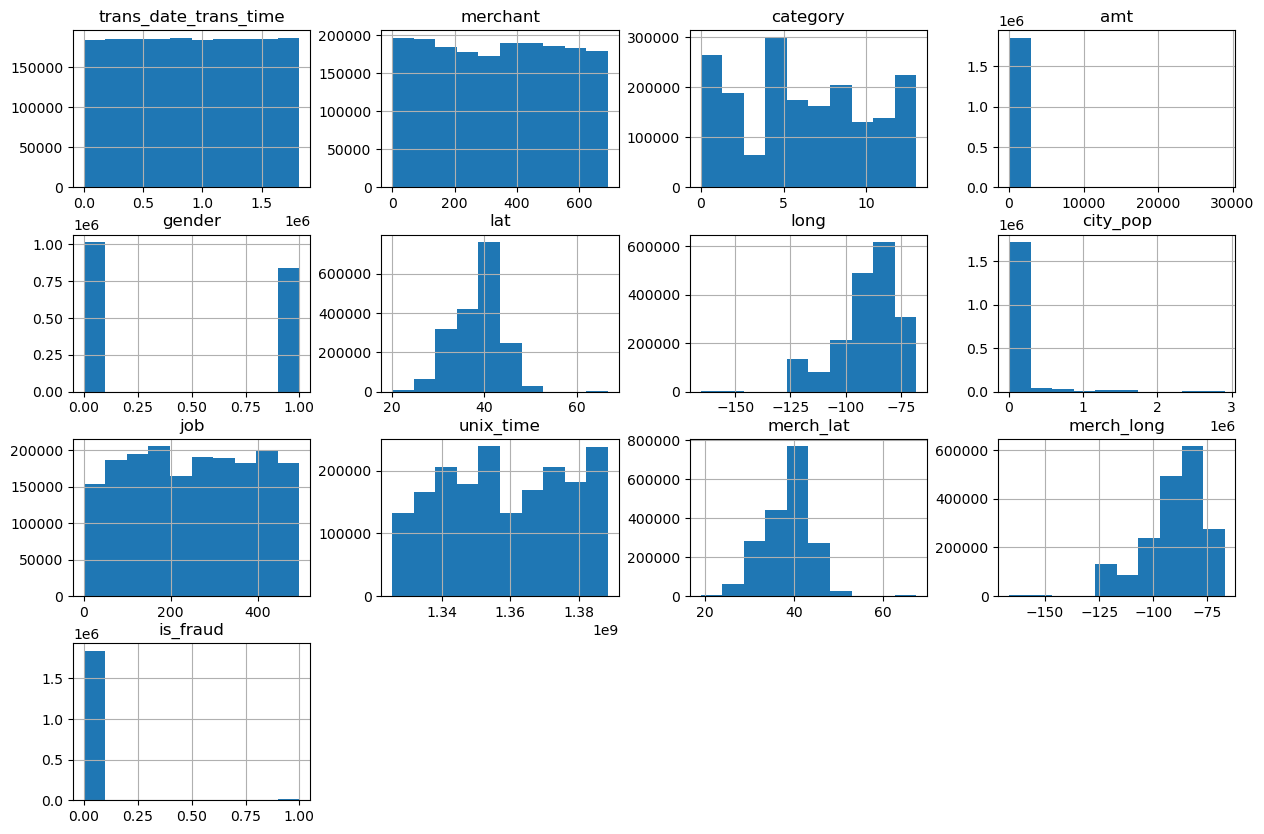

In [23]:
df.hist(figsize = (15,10))
plt.show()

## Fraud vs Non-Fraud Transactions

In [24]:
df['is_fraud'].value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

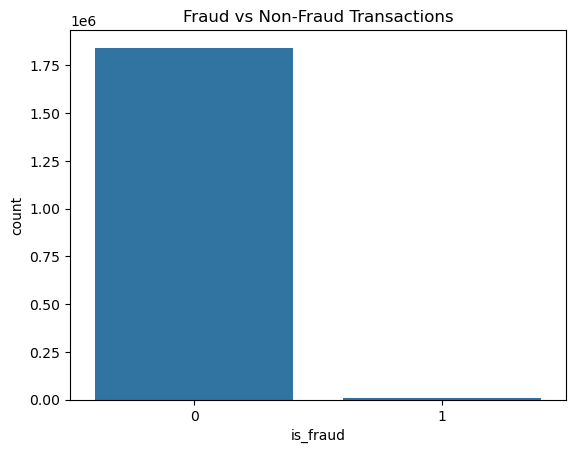

In [25]:
sns.countplot(x = 'is_fraud', data = df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

Interpretation

- Majority of transactions are non-fraud (0).

- Fraud cases (1) are very less.

- Dataset is highly imbalanced.

## Correlation using Heatmap

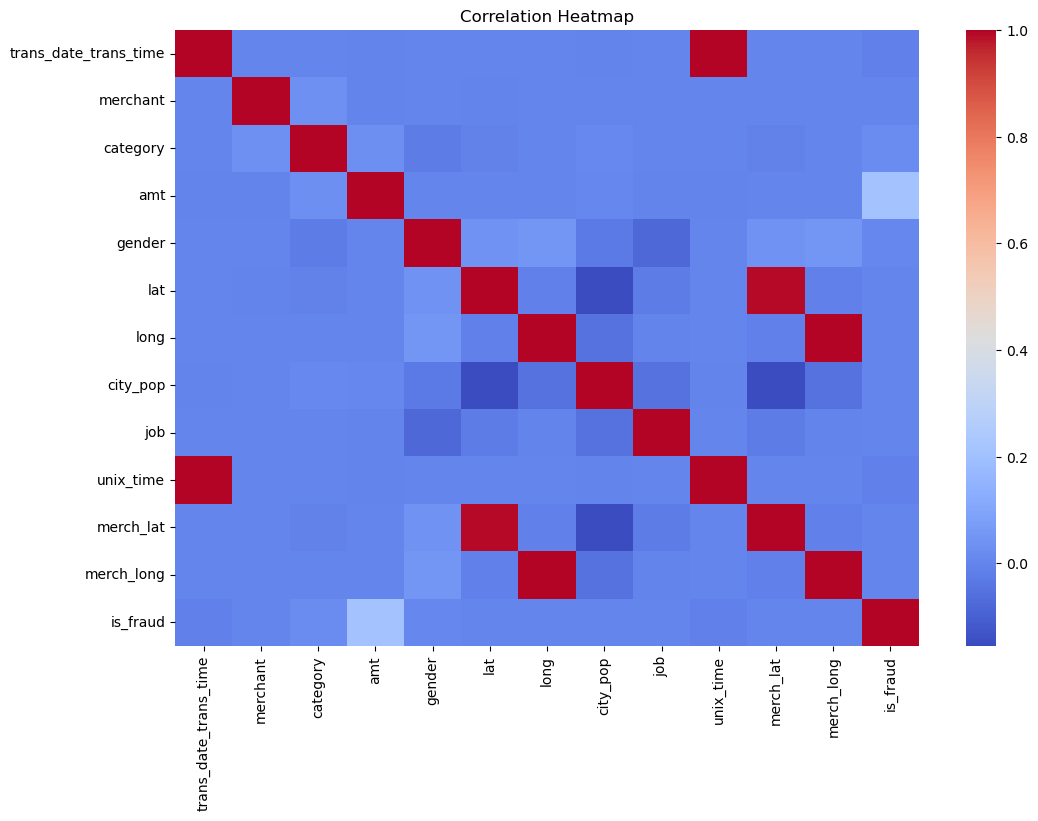

In [26]:
plt.figure(figsize  = (12,8))
sns.heatmap(df.corr(), cmap  = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Interpretation

- Shows relationships between features.

- Helps identify important variables.

- Useful for feature selection.

## Pairplot 

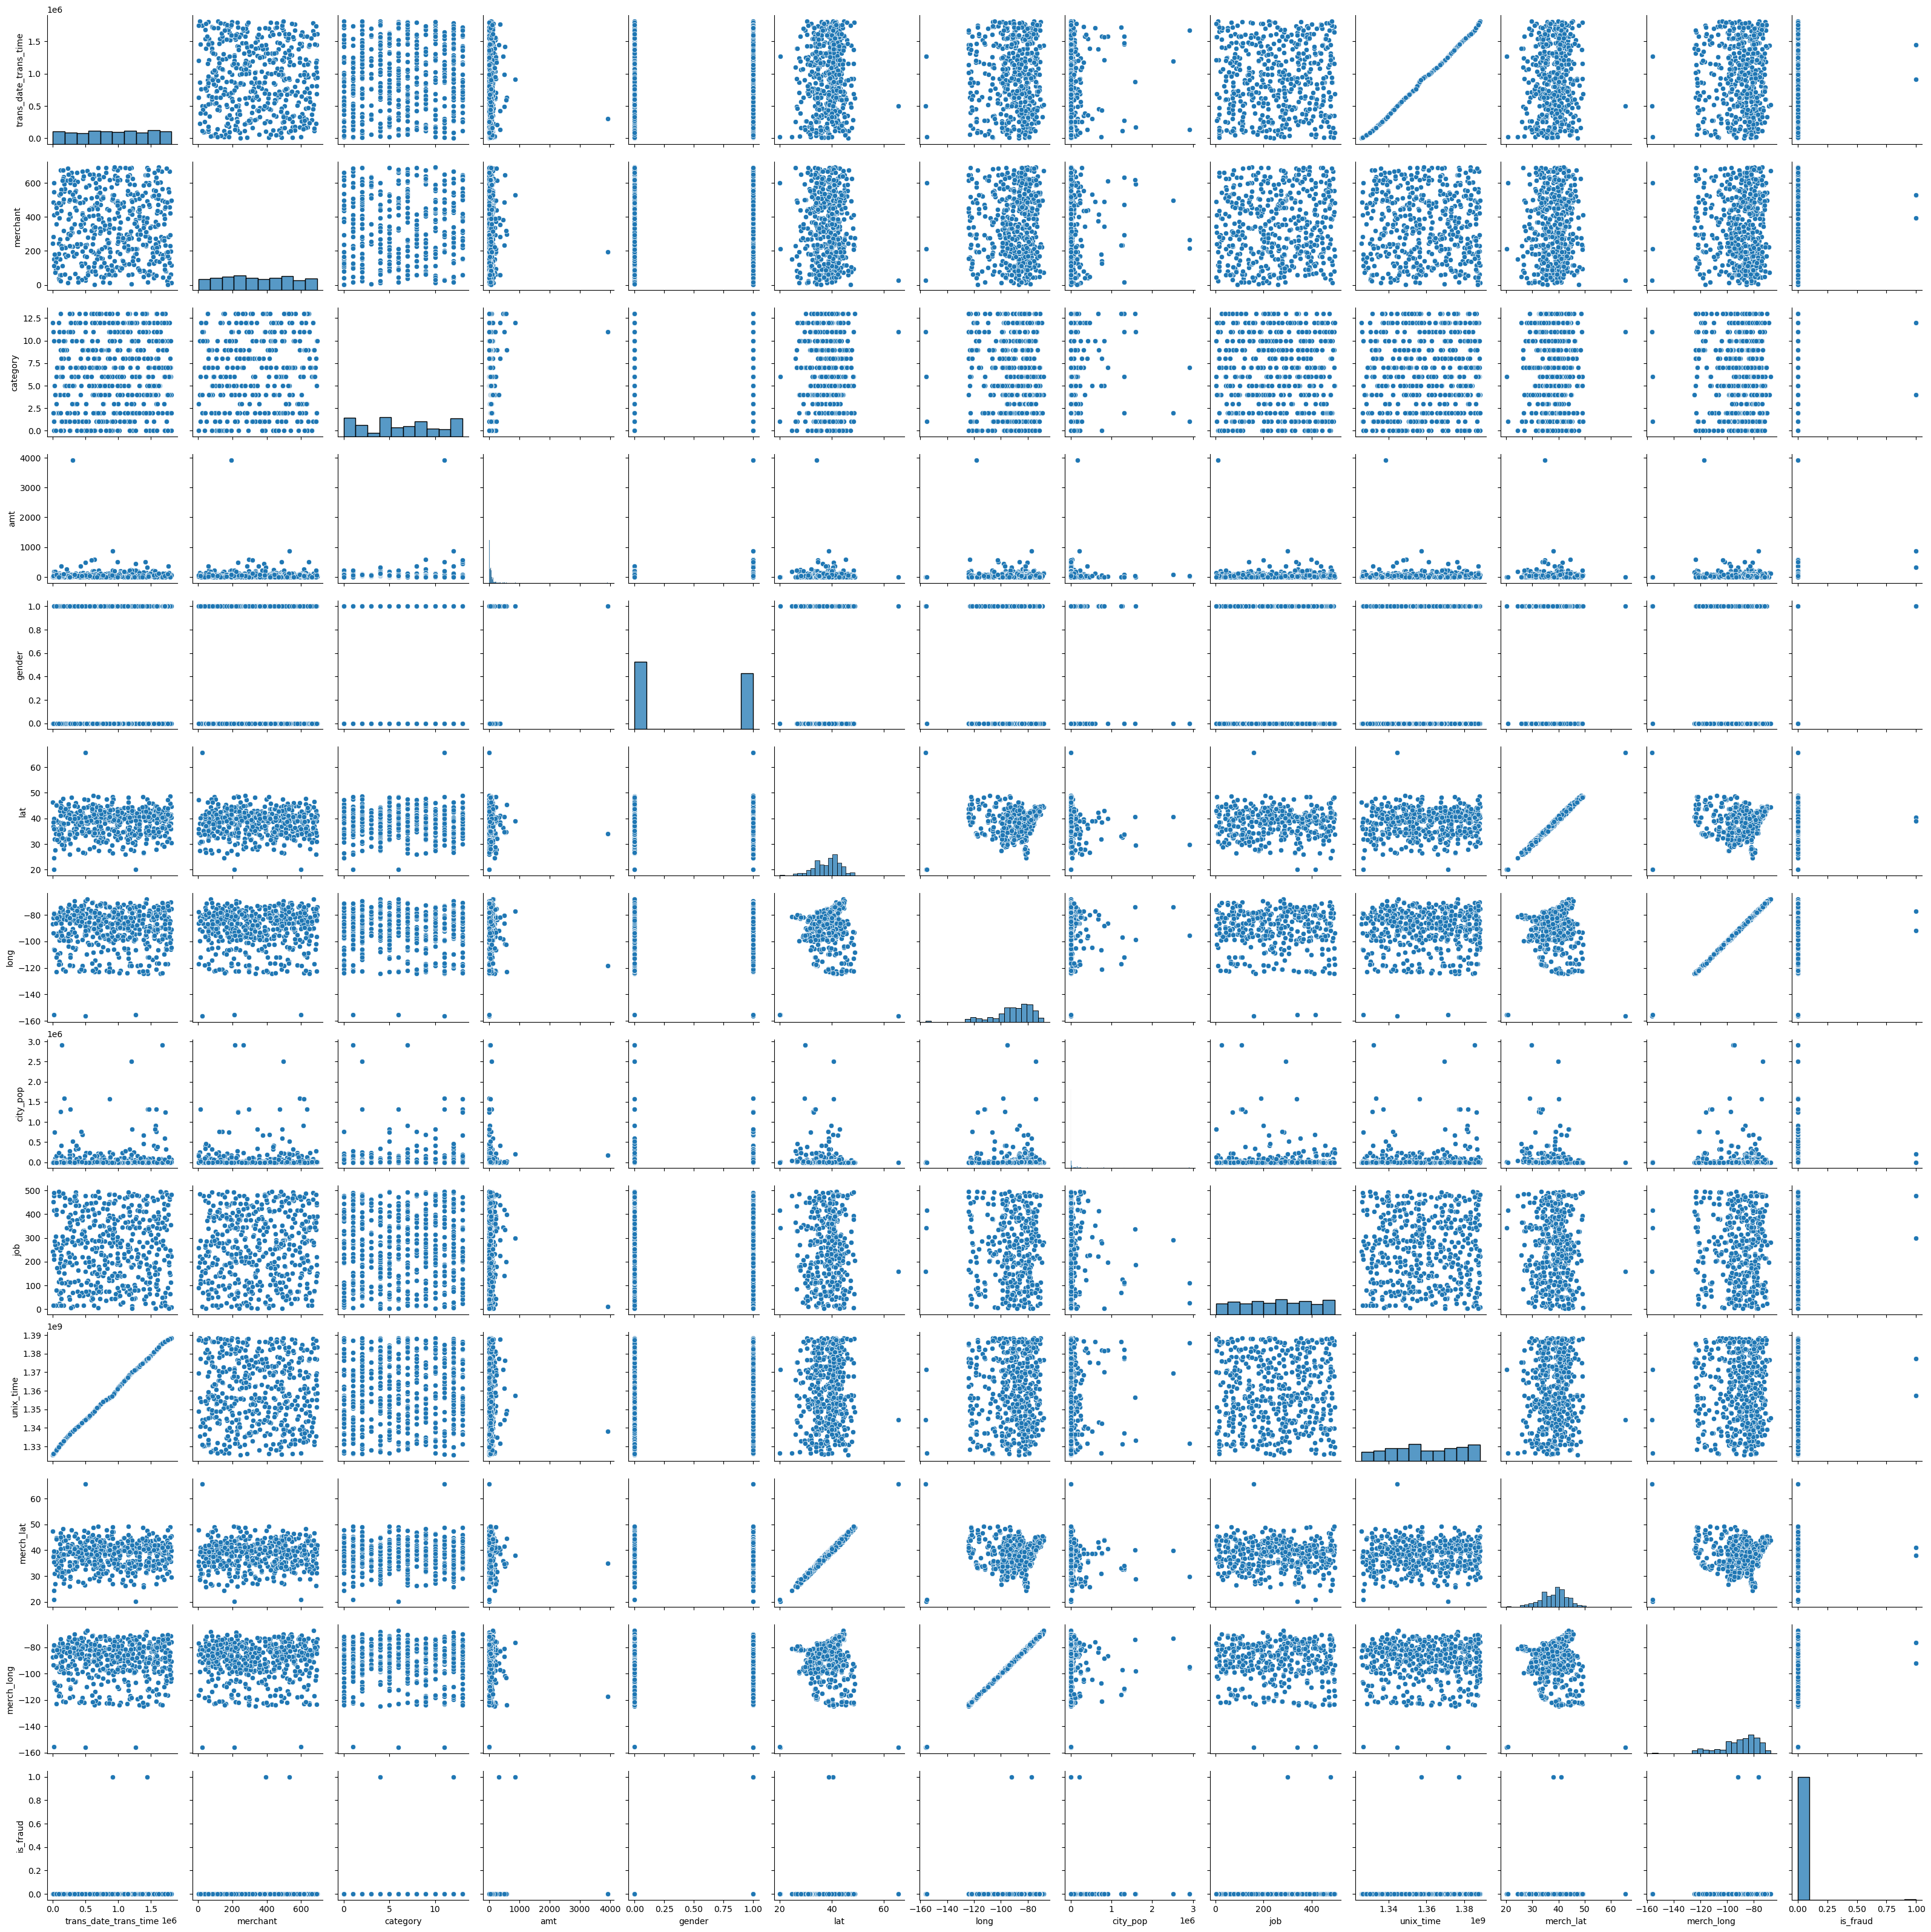

In [27]:
sns.pairplot(df.sample(500))

Interpretation

- Shows patterns between features.

- Helps identify clusters and trends.

- Useful in understanding fraud behavior.

# 4. Visualisation:

● Perform visualisation on different columns in the dataset.
    
● Must use: Boxplot, countplot, Heatmap, Pairplot, barplot.

## Boxplot (Outlier Analysis)

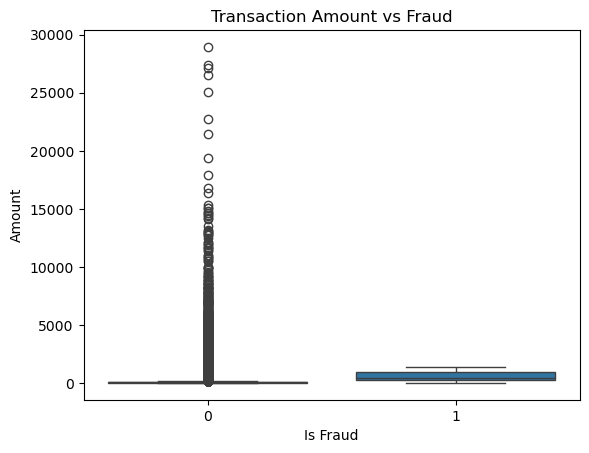

In [28]:
sns.boxplot(x = 'is_fraud', y = 'amt', data = df)
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.title('Transaction Amount vs Fraud')
plt.show()

Interpretation

- Fraud transactions often show unusual or extreme values.

- Presence of outliers is observed.

## Barplot (Category vs Amount) 

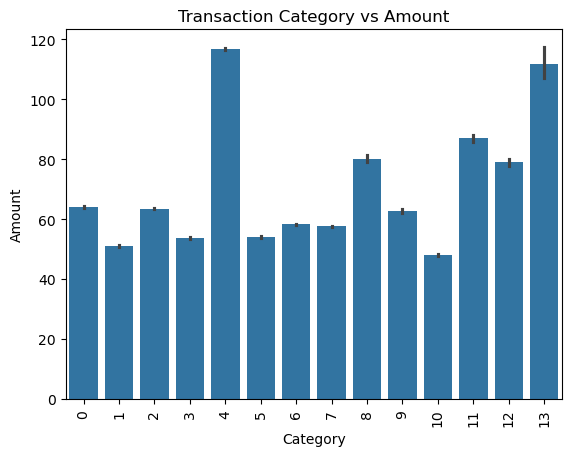

In [29]:
sns.barplot(x = 'category', y = 'amt', data = df)
plt.xticks(rotation=90)
plt.title("Transaction Category vs Amount")
plt.xlabel('Category')
plt.ylabel('Amount')
plt.show()

Interpretation

- Some categories show higher transaction amounts.

- Certain categories may be more prone to fraud

## Category vs Fraud

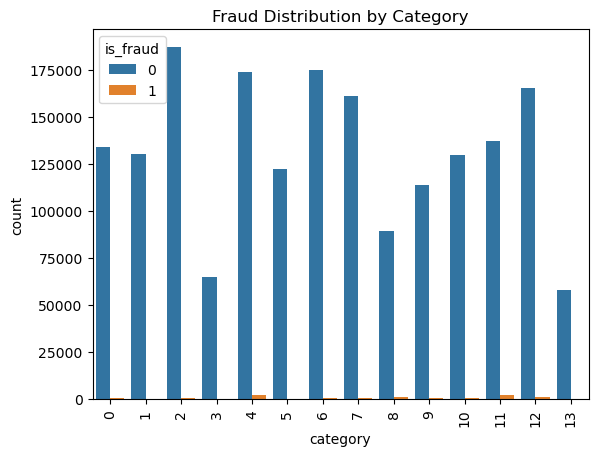

In [30]:
sns.countplot(x='category', hue='is_fraud', data=df)
plt.xticks(rotation=90)
plt.title("Fraud Distribution by Category")
plt.show()

Insight

- Which categories have more fraud
- Strong business insight

## Top Merchants with Fraud

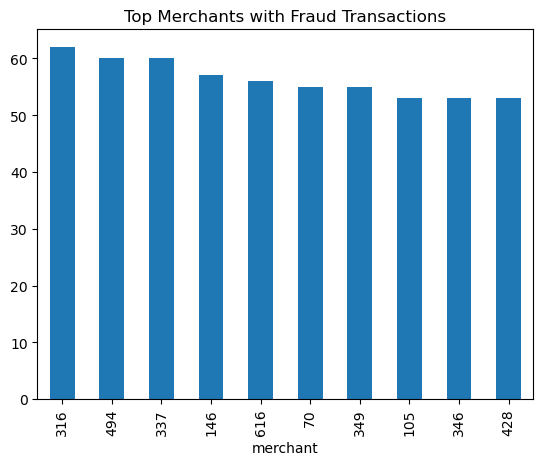

In [31]:
top_merchants = df.groupby('merchant')['is_fraud'].sum().sort_values(ascending = False ).head(10)

top_merchants.plot(kind = 'bar')
plt.title('Top Merchants with Fraud Transactions')
plt.show()

# 5. Feature Scaling

### Split Features & Target

In [260]:
df.shape

(1852394, 13)

## Train-Test Split

In [261]:
from sklearn.model_selection import train_test_split

In [262]:
X = df_sample.drop('is_fraud', axis = 1)
y = df_sample['is_fraud']

In [263]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, stratify = y, random_state = 42)

In [264]:
df_sample = df.sample(100000,random_state = 50)

## Apply Scaling

In [265]:
from sklearn.preprocessing import StandardScaler

In [266]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [267]:
df_sample['is_fraud'].value_counts()

is_fraud
0    99522
1      478
Name: count, dtype: int64

### Importing Smote 

In [268]:
from imblearn.over_sampling import SMOTE

### Applying SMOTE on training data

In [269]:
smote = SMOTE(random_state = 42)
X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

# Check New Class Distribution

In [270]:
y_train_smote.value_counts()

is_fraud
0    79618
1    79618
Name: count, dtype: int64

# 6. Model Selection & Fitting:

● Train Test split , Fit any 4 model suitable for the dataset and compare the accuracies.

# 7. Model Evaluation :

● Classification report, F1 SCORE, Accuracy score, Confusion matrix.

In [320]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [367]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix

# Logistics Regression

In [273]:
log_model = LogisticRegression(max_iter = 1000,class_weight="balanced") 

log_model.fit(X_train_smote, y_train_smote)

LogisticRegression(class_weight='balanced', max_iter=1000)

-  Max_iter=1000 is used because sometimes Logistic Regression needs more itrations to converge.

#### Prediction

In [274]:
# Test Prediction
y_pred_test_lr = log_model.predict(X_test_scaled)

# Training Prediction
y_pred_train_lr = log_model.predict(X_train_smote)

C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


#### Accuracy Score 

In [275]:
train_accuracy = accuracy_score(y_train_smote, y_pred_train_lr)
test_accuracy = accuracy_score(y_test, y_pred_test_lr)

print("Training Accuracy:", train_accuracy * 100)
print("Test Accuracy:", test_accuracy * 100)

Training Accuracy: 88.42661207264689
Test Accuracy: 66.295


### Logistics Regression Accuracy

In [276]:
logistic_test_accuracy = accuracy_score(y_test,y_pred_test_lr)

print('Logistic Regression Accuracy:',logistic_test_accuracy * 100)

Logistic Regression Accuracy: 66.295


#### Overfitting/ Underfitting

In [277]:
diff = abs(train_accuracy - test_accuracy)

if train_accuracy > test_accuracy and diff > 0.05:
    print("Model is Overfitting")
elif test_accuracy > train_accuracy and diff > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Balanced")

Model is Overfitting


#### Classification Report

In [278]:
print(classification_report(y_test,y_pred_test_lr))

              precision    recall  f1-score   support

           0       1.00      0.66      0.80     19904
           1       0.01      0.75      0.02        96

    accuracy                           0.66     20000
   macro avg       0.50      0.71      0.41     20000
weighted avg       0.99      0.66      0.79     20000



#### Confusion Matrix

In [279]:
cm = confusion_matrix(y_test,y_pred_test_lr)
print(cm)

[[13187  6717]
 [   24    72]]


#### Visualization

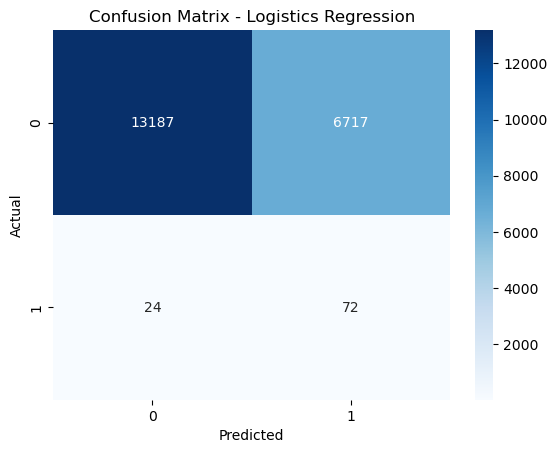

In [313]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistics Regression')
plt.show()

#### F1 Score

In [281]:
f1 = f1_score(y_test, y_pred_test_lr)

print('F1 Score:', f1 * 100)

F1 Score: 2.091503267973856


#### Logistics Regression Coefficients (Feature Importance)

In [282]:
feature_importance = pd.Series(
    log_model.coef_[0],
    index = X.columns
)

print(feature_importance.sort_values(ascending = False))

amt                      1.202914e-02
merchant                 2.908826e-04
job                      1.234742e-04
category                 1.677503e-05
lat                      5.139573e-06
merch_lat                4.965080e-06
unix_time               -1.631854e-09
trans_date_trans_time   -1.738776e-07
city_pop                -2.541403e-07
gender                  -5.036330e-06
long                    -5.266029e-06
merch_long              -5.409140e-06
dtype: float64


#### Visualization

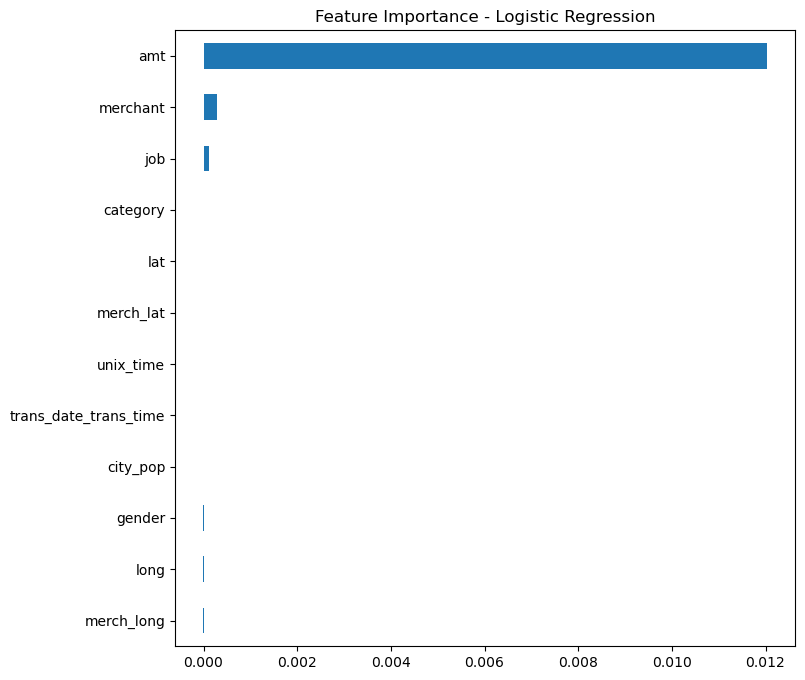

In [283]:
feature_importance.sort_values().plot(kind = 'barh', figsize = (8,8))

plt.title('Feature Importance - Logistic Regression')

plt.show()

# Decision Tree Model

In [284]:
dt_model = DecisionTreeClassifier(random_state = 50)

dt_model.fit(X_train_smote,y_train_smote)

DecisionTreeClassifier(random_state=50)

#### Prediction

In [285]:
# Prediction on Test Data
y_pred_test_dt = dt_model.predict(X_test)

# Prediction on Training Data
y_pred_train_dt = dt_model.predict(X_train_smote)

#### Accuracy Score

In [286]:
train_accuracy = accuracy_score(y_train_smote,y_pred_train_dt)
test_accuracy = accuracy_score(y_test,y_pred_test_dt)

print('Training Accuracy:', train_accuracy * 100)
print('Test Accuracy:', test_accuracy * 100)

Training Accuracy: 100.0
Test Accuracy: 98.06


#### Decision Tree Accuracy

In [287]:
dt_test_accuracy =  accuracy_score(y_test,y_pred_test_dt)

print('Decision Tree Accuracy:', dt_test_accuracy * 100)

Decision Tree Accuracy: 98.06


#### Check Overfitting / Underfitting

In [288]:
diff = abs(train_accuracy - test_accuracy)

if train_accuracy > test_accuracy and diff > 0.05:
    print("Model is Overfitting")
elif test_accuracy > train_accuracy and diff > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Balanced")

Model is Balanced


#### Classification Report

In [289]:
print(classification_report(y_test,y_pred_test_dt))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     19904
           1       0.15      0.65      0.24        96

    accuracy                           0.98     20000
   macro avg       0.57      0.81      0.62     20000
weighted avg       0.99      0.98      0.99     20000



#### Confusion Matrix

In [290]:
cm = confusion_matrix(y_test,y_pred_test_dt)
print(cm)

[[19550   354]
 [   34    62]]


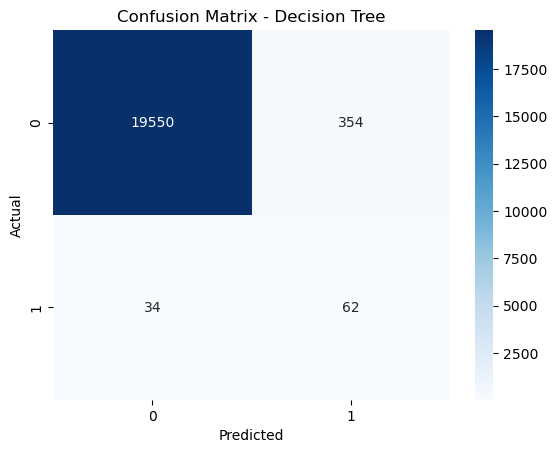

In [311]:
cm = confusion_matrix(y_test, y_pred_test_dt)

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

#### Feature Importance

In [292]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

print(feature_importance)

amt                      0.670778
category                 0.069882
unix_time                0.050464
city_pop                 0.033711
trans_date_trans_time    0.032453
job                      0.025908
merchant                 0.025310
lat                      0.022961
long                     0.021516
merch_long               0.016601
merch_lat                0.015221
gender                   0.015194
dtype: float64


#### Visualization:

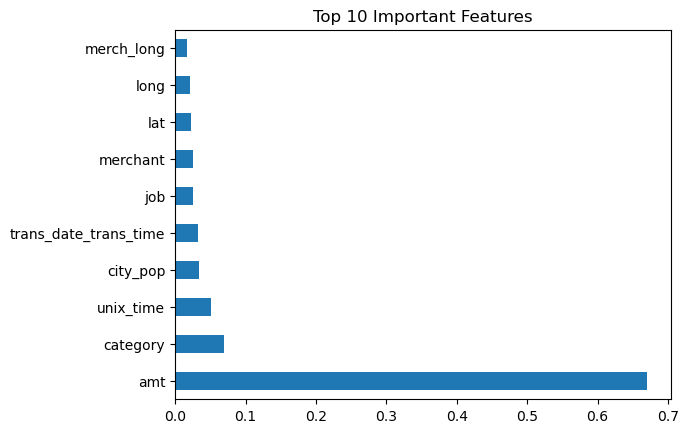

In [293]:
feature_importance.head(10).plot(kind='barh')

plt.title('Top 10 Important Features')

plt.show()

# Random Forest

In [328]:
rf_model = RandomForestClassifier(class_weight="balanced",
    n_estimators=100,
    random_state=42)

rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(class_weight='balanced', random_state=42)

#### Prediction

In [329]:
# Test Prediction
y_pred_test_rf = rf_model.predict(X_test)

# Training Prediction
y_pred_train_rf = rf_model.predict(X_train_smote)

#### Accuracy Score

In [330]:
train_accuracy = accuracy_score(y_train_smote, y_pred_train_rf)
test_accuracy = accuracy_score(y_test, y_pred_test_rf)

print('Training Accuracy:', train_accuracy * 100)
print('Testing Accuracy:', test_accuracy * 100)

Training Accuracy: 100.0
Testing Accuracy: 99.1


## Random Forest Accuracy 

In [331]:
rf_test_accuracy = accuracy_score(y_test, y_pred_test_rf)

print('Random Forest Accuracy:', rf_test_accuracy * 100)

Random Forest Accuracy: 99.1


#### Check Overfitting/ Underfitting

In [332]:
diff = abs(train_accuracy - test_accuracy)

if train_accuracy > test_accuracy and diff > 0.05:
    print("Model is Overfitting")
elif test_accuracy > train_accuracy and diff > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Balanced")

Model is Balanced


#### Classification Report

In [300]:
print(classification_report(y_test, y_pred_test_rf))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     19904
           1       0.27      0.52      0.36        96

    accuracy                           0.99     20000
   macro avg       0.63      0.76      0.68     20000
weighted avg       0.99      0.99      0.99     20000



#### Confusion Matrix

In [302]:
cm = confusion_matrix(y_test,y_pred_test_rf)
print(cm)

[[19770   134]
 [   46    50]]


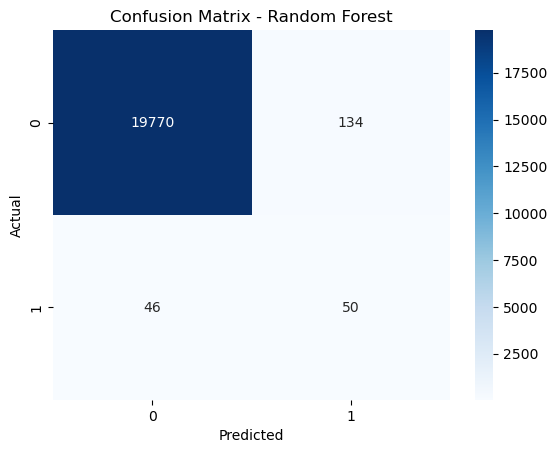

In [309]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

#### Feature Importance

In [316]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

print(feature_importance)

amt                      0.566275
category                 0.076634
unix_time                0.056475
trans_date_trans_time    0.055792
merchant                 0.040589
city_pop                 0.039199
job                      0.031378
long                     0.030606
lat                      0.029865
merch_long               0.027188
merch_lat                0.023778
gender                   0.022221
dtype: float64


#### Visualization

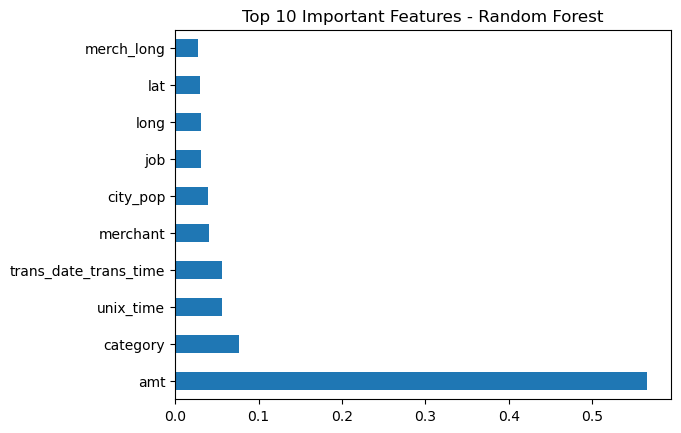

In [317]:
feature_importance.head(10).plot(kind = 'barh')

plt.title('Top 10 Important Features - Random Forest')

plt.show()

## XGBoost

In [349]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

#### Prediction

In [350]:
# Test prediction
y_pred_test_xgb = xgb_model.predict(X_test_scaled)

# Training prediction
y_pred_train_xgb = xgb_model.predict(X_train_smote)

#### Accuracy

In [351]:
train_accuracy = accuracy_score(y_train_smote, y_pred_train_xgb)
test_accuracy = accuracy_score(y_test, y_pred_test_xgb)

print("Training Accuracy:", train_accuracy * 100)
print("Test Accuracy:", test_accuracy * 100)

Training Accuracy: 99.26712552437891
Test Accuracy: 99.52


####  XGBoost Accuracy

In [383]:
xgb_test_accuracy = accuracy_score(y_test, y_pred_test_xgb)

print('Random Forest Accuracy:', rf_test_accuracy * 100)

Random Forest Accuracy: 99.1


#### Checking Overfitting/Underfitting

In [352]:
diff = abs(train_accuracy - test_accuracy)

if train_accuracy > test_accuracy and diff > 0.05:
    print("Model is Overfitting")
elif test_accuracy > train_accuracy and diff > 0.05:
    print("Model is Underfitting")
else:
    print("Model is Balanced")

Model is Balanced


#### Classification Report

In [353]:
print(classification_report(y_test,y_pred_test_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19904
           1       0.00      0.00      0.00        96

    accuracy                           1.00     20000
   macro avg       0.50      0.50      0.50     20000
weighted avg       0.99      1.00      0.99     20000



C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Confusion Matrix

In [354]:
cm = confusion_matrix(y_test, y_pred_test_xgb)
print(cm)

[[19904     0]
 [   96     0]]


#### Visualization:

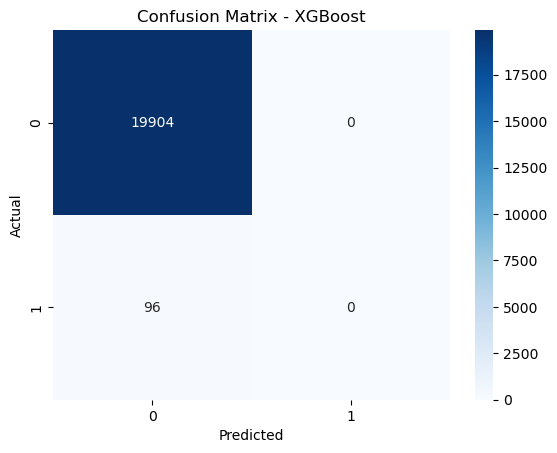

In [355]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### F1 Score

In [357]:
f1 = f1_score(y_test, y_pred_test_xgb)

print('F1 Score:', f1 * 100)

F1 Score: 0.0


#### Feature Importance

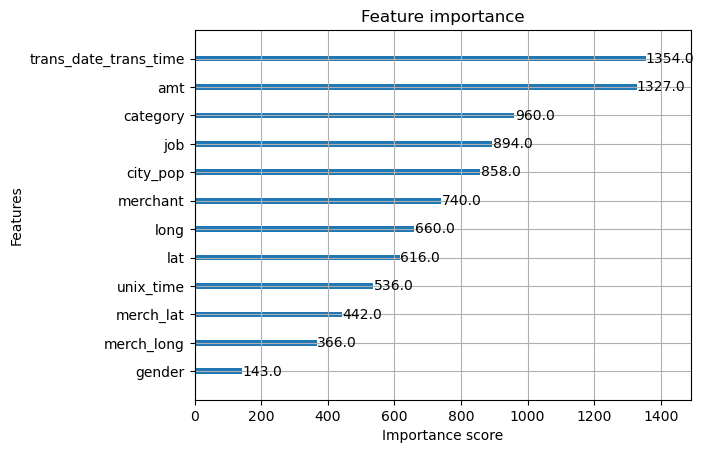

In [387]:
from xgboost import plot_importance

plot_importance(xgb_model)
plt.show()

# Comparison Between the models

In [365]:
results = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred_test_lr) * 100,
        accuracy_score(y_test, y_pred_test_dt) * 100,
        accuracy_score(y_test, y_pred_test_rf) * 100,
        accuracy_score(y_test, y_pred_test_xgb) * 100
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_test_lr),
        precision_score(y_test, y_pred_test_dt),
        precision_score(y_test, y_pred_test_rf),
        precision_score(y_test, y_pred_test_xgb)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_test_lr),
        recall_score(y_test, y_pred_test_dt),
        recall_score(y_test, y_pred_test_rf),
        recall_score(y_test, y_pred_test_xgb)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_test_lr),
        f1_score(y_test, y_pred_test_dt),
        f1_score(y_test, y_pred_test_rf),
        f1_score(y_test, y_pred_test_xgb) 
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    66.295   0.010605  0.750000  0.020915
1        Decision Tree    98.060   0.149038  0.645833  0.242188
2        Random Forest    99.100   0.271739  0.520833  0.357143
3              XGBoost    99.520   0.000000  0.000000  0.000000


C:\Users\aryan\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Sort by Best Model

In [368]:
results = results.sort_values(by="F1 Score", ascending=False)
print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
2        Random Forest    99.100   0.271739  0.520833  0.357143
1        Decision Tree    98.060   0.149038  0.645833  0.242188
0  Logistic Regression    66.295   0.010605  0.750000  0.020915
3              XGBoost    99.520   0.000000  0.000000  0.000000


## Visual Comparison

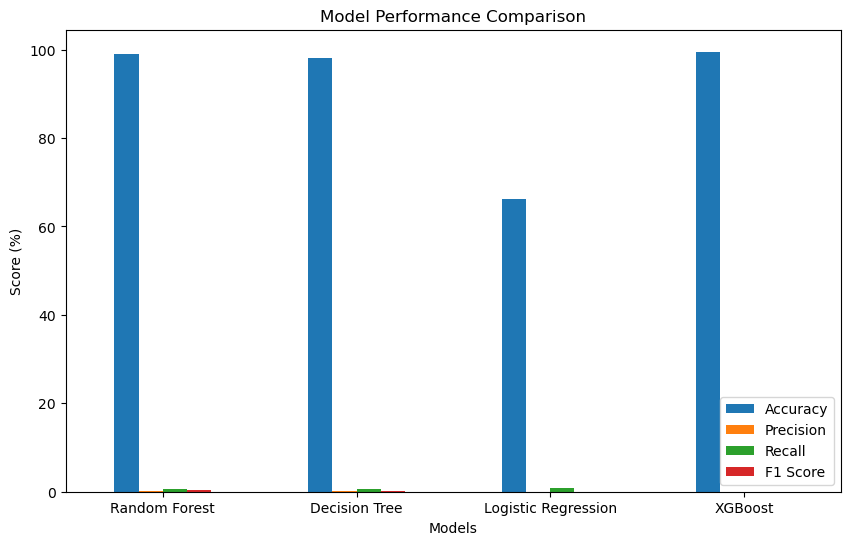

In [384]:
results.set_index('Model').plot(kind = 'bar', figsize = (10,6))

plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xlabel('Models')
plt.xticks(rotation=0)
plt.legend(loc = 'lower right')

plt.show()

# Key Insights

- The dataset was highly imbalanced, with significantly fewer fraudulent transactions compared to normal transactions. To address this issue, SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the training data.

- Multiple machine learning models including Logistic Regression, Decision Tree, Random Forest, and XGBoost were trained and evaluated to identify the best model for fraud detection.

- Random Forest achieved the highest overall performance, showing superior accuracy and a better balance between precision and recall compared to the other models.

- Logistic Regression showed lower performance, indicating that linear models may struggle to capture the complex patterns present in fraudulent transaction data.

- Tree-based models such as Decision Tree and Random Forest performed better, as they can capture nonlinear relationships and interactions among features.

- Evaluation metrics such as Precision, Recall, and F1-score were used instead of relying solely on accuracy, since fraud detection problems involve highly imbalanced datasets.

- Visualization of model performance through a bar chart comparison helped clearly identify the best performing model among all candidates.

# Conclusion 
- The project focused on detecting fraudulent credit card transactions using machine learning techniques.

- The dataset was highly imbalanced, and SMOTE (Synthetic Minority Oversampling Technique) was applied to balance the training data.

- Four machine learning models were implemented and evaluated: Logistic Regression, Decision Tree, Random Forest, and XGBoost.
Model performance was evaluated using Accuracy, Precision, Recall, and F1-score to ensure proper assessment of fraud detection capability.

- Tree-based models performed better than the linear model, indicating their ability to capture complex patterns in the data.
Random Forest achieved the best overall performance among the models tested, showing the highest accuracy and balanced precision-recall values.
- Visualization of model performance helped clearly compare the effectiveness of different algorithms.
- The results demonstrate that machine learning models can effectively identify patterns associated with fraudulent transactions.

###### 